# Praktikum K-Means
**Nama:** Mikhael Josua    
**Sumber:** 42324023
**Prodi:** D3 Teknologi Informasi

## 1. Import pustaka
Pandas digunakan untuk membaca data, Matplotlib untuk visualisasi, dan scikit-learn untuk scaling serta K-Means. `random_state=42` dan `n_init=10` membuat hasil lebih konsisten saat dijalankan ulang.

In [1]:
# Jika pustaka belum tersedia, jalankan baris berikut dengan menghapus tanda #:
# %pip install pandas numpy matplotlib scikit-learn

from pathlib import Path
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
RANDOM_STATE = 42
N_INIT = 10

## 2. Membaca dataset
Setiap baris mewakili satu pelanggan. `CustomerID` merupakan identitas, bukan fitur klasterisasi. `Genre` tidak digunakan karena praktikum berfokus pada fitur numerik.

In [2]:
# Salinan dataset lampiran, bukan data sintetis.
CSV_EMBEDDED = 'CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)\n0001,Male,19,15,39\n0002,Male,21,15,81\n0003,Female,20,16,6\n0004,Female,23,16,77\n0005,Female,31,17,40\n0006,Female,22,17,76\n0007,Female,35,18,6\n0008,Female,23,18,94\n0009,Male,64,19,3\n0010,Female,30,19,72\n0011,Male,67,19,14\n0012,Female,35,19,99\n0013,Female,58,20,15\n0014,Female,24,20,77\n0015,Male,37,20,13\n0016,Male,22,20,79\n0017,Female,35,21,35\n0018,Male,20,21,66\n0019,Male,52,23,29\n0020,Female,35,23,98\n0021,Male,35,24,35\n0022,Male,25,24,73\n0023,Female,46,25,5\n0024,Male,31,25,73\n0025,Female,54,28,14\n0026,Male,29,28,82\n0027,Female,45,28,32\n0028,Male,35,28,61\n0029,Female,40,29,31\n0030,Female,23,29,87\n0031,Male,60,30,4\n0032,Female,21,30,73\n0033,Male,53,33,4\n0034,Male,18,33,92\n0035,Female,49,33,14\n0036,Female,21,33,81\n0037,Female,42,34,17\n0038,Female,30,34,73\n0039,Female,36,37,26\n0040,Female,20,37,75\n0041,Female,65,38,35\n0042,Male,24,38,92\n0043,Male,48,39,36\n0044,Female,31,39,61\n0045,Female,49,39,28\n0046,Female,24,39,65\n0047,Female,50,40,55\n0048,Female,27,40,47\n0049,Female,29,40,42\n0050,Female,31,40,42\n0051,Female,49,42,52\n0052,Male,33,42,60\n0053,Female,31,43,54\n0054,Male,59,43,60\n0055,Female,50,43,45\n0056,Male,47,43,41\n0057,Female,51,44,50\n0058,Male,69,44,46\n0059,Female,27,46,51\n0060,Male,53,46,46\n0061,Male,70,46,56\n0062,Male,19,46,55\n0063,Female,67,47,52\n0064,Female,54,47,59\n0065,Male,63,48,51\n0066,Male,18,48,59\n0067,Female,43,48,50\n0068,Female,68,48,48\n0069,Male,19,48,59\n0070,Female,32,48,47\n0071,Male,70,49,55\n0072,Female,47,49,42\n0073,Female,60,50,49\n0074,Female,60,50,56\n0075,Male,59,54,47\n0076,Male,26,54,54\n0077,Female,45,54,53\n0078,Male,40,54,48\n0079,Female,23,54,52\n0080,Female,49,54,42\n0081,Male,57,54,51\n0082,Male,38,54,55\n0083,Male,67,54,41\n0084,Female,46,54,44\n0085,Female,21,54,57\n0086,Male,48,54,46\n0087,Female,55,57,58\n0088,Female,22,57,55\n0089,Female,34,58,60\n0090,Female,50,58,46\n0091,Female,68,59,55\n0092,Male,18,59,41\n0093,Male,48,60,49\n0094,Female,40,60,40\n0095,Female,32,60,42\n0096,Male,24,60,52\n0097,Female,47,60,47\n0098,Female,27,60,50\n0099,Male,48,61,42\n0100,Male,20,61,49\n0101,Female,23,62,41\n0102,Female,49,62,48\n0103,Male,67,62,59\n0104,Male,26,62,55\n0105,Male,49,62,56\n0106,Female,21,62,42\n0107,Female,66,63,50\n0108,Male,54,63,46\n0109,Male,68,63,43\n0110,Male,66,63,48\n0111,Male,65,63,52\n0112,Female,19,63,54\n0113,Female,38,64,42\n0114,Male,19,64,46\n0115,Female,18,65,48\n0116,Female,19,65,50\n0117,Female,63,65,43\n0118,Female,49,65,59\n0119,Female,51,67,43\n0120,Female,50,67,57\n0121,Male,27,67,56\n0122,Female,38,67,40\n0123,Female,40,69,58\n0124,Male,39,69,91\n0125,Female,23,70,29\n0126,Female,31,70,77\n0127,Male,43,71,35\n0128,Male,40,71,95\n0129,Male,59,71,11\n0130,Male,38,71,75\n0131,Male,47,71,9\n0132,Male,39,71,75\n0133,Female,25,72,34\n0134,Female,31,72,71\n0135,Male,20,73,5\n0136,Female,29,73,88\n0137,Female,44,73,7\n0138,Male,32,73,73\n0139,Male,19,74,10\n0140,Female,35,74,72\n0141,Female,57,75,5\n0142,Male,32,75,93\n0143,Female,28,76,40\n0144,Female,32,76,87\n0145,Male,25,77,12\n0146,Male,28,77,97\n0147,Male,48,77,36\n0148,Female,32,77,74\n0149,Female,34,78,22\n0150,Male,34,78,90\n0151,Male,43,78,17\n0152,Male,39,78,88\n0153,Female,44,78,20\n0154,Female,38,78,76\n0155,Female,47,78,16\n0156,Female,27,78,89\n0157,Male,37,78,1\n0158,Female,30,78,78\n0159,Male,34,78,1\n0160,Female,30,78,73\n0161,Female,56,79,35\n0162,Female,29,79,83\n0163,Male,19,81,5\n0164,Female,31,81,93\n0165,Male,50,85,26\n0166,Female,36,85,75\n0167,Male,42,86,20\n0168,Female,33,86,95\n0169,Female,36,87,27\n0170,Male,32,87,63\n0171,Male,40,87,13\n0172,Male,28,87,75\n0173,Male,36,87,10\n0174,Male,36,87,92\n0175,Female,52,88,13\n0176,Female,30,88,86\n0177,Male,58,88,15\n0178,Male,27,88,69\n0179,Male,59,93,14\n0180,Male,35,93,90\n0181,Female,37,97,32\n0182,Female,32,97,86\n0183,Male,46,98,15\n0184,Female,29,98,88\n0185,Female,41,99,39\n0186,Male,30,99,97\n0187,Female,54,101,24\n0188,Male,28,101,68\n0189,Female,41,103,17\n0190,Female,36,103,85\n0191,Female,34,103,23\n0192,Female,32,103,69\n0193,Male,33,113,8\n0194,Female,38,113,91\n0195,Female,47,120,16\n0196,Female,35,120,79\n0197,Female,45,126,28\n0198,Male,32,126,74\n0199,Male,32,137,18\n0200,Male,30,137,83'

paths = [Path("Mall_Customers.csv"), Path("/content/Mall_Customers.csv")]
csv_path = next((p for p in paths if p.is_file()), None)
df = pd.read_csv(csv_path if csv_path is not None else StringIO(CSV_EMBEDDED))
df.columns = df.columns.str.strip()
required = ["CustomerID", "Age", "Annual Income (k$)", "Spending Score (1-100)"]
if not set(required).issubset(df.columns):
    raise ValueError("Kolom dataset tidak sesuai dengan Mall Customers.")
print("Sumber:", str(csv_path) if csv_path else "dataset lampiran yang disertakan dalam notebook")
print(f"Ukuran data: {df.shape[0]} pelanggan × {df.shape[1]} kolom")
display(df.head())

Sumber: Mall_Customers.csv
Ukuran data: 200 pelanggan × 5 kolom


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Pemeriksaan data
Nilai kosong dan duplikasi diperiksa sebelum membangun model. Statistik deskriptif menunjukkan rentang setiap fitur. Tidak ada baris yang dihapus otomatis; notebook berhenti bila fitur numerik mengandung nilai kosong atau tidak valid.

In [3]:
display(df.isna().sum().rename("Missing values").to_frame())
print("Jumlah baris duplikat:", int(df.duplicated().sum()))
print("CustomerID unik:", df["CustomerID"].is_unique)
features_2d = ["Annual Income (k$)", "Spending Score (1-100)"]
features_3d = ["Age", *features_2d]
df[features_3d] = df[features_3d].apply(pd.to_numeric, errors="raise")
if df[features_3d].isna().any().any():
    raise ValueError("Fitur klasterisasi memiliki nilai kosong; perbaiki data terlebih dahulu.")
if not np.isfinite(df[features_3d].to_numpy()).all():
    raise ValueError("Fitur klasterisasi memiliki nilai tidak terhingga.")
display(df.describe().round(2))

,Missing values
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Jumlah baris duplikat: 0
CustomerID unik: True


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


## 4. Visualisasi awal dua fitur
Grafik menampilkan hubungan pendapatan tahunan (ribuan dolar) dengan skor belanja (1–100). Titik yang berdekatan memiliki karakteristik serupa.

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


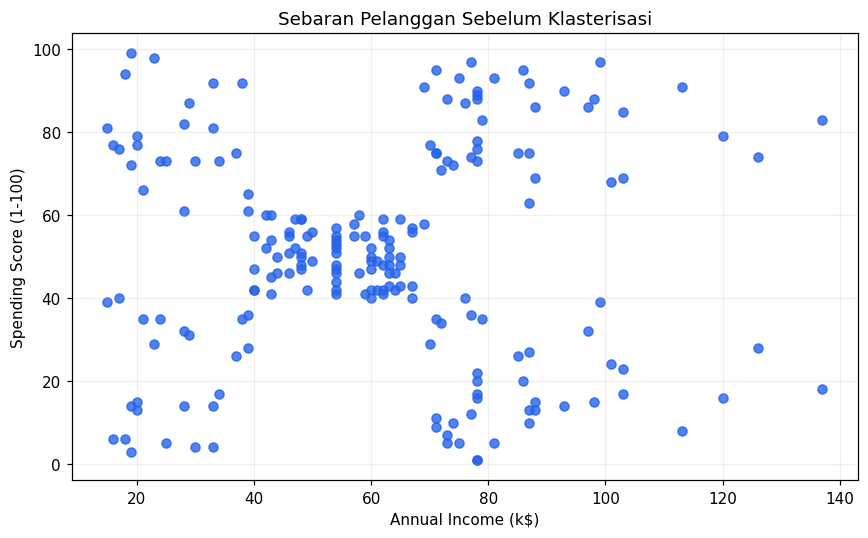

In [4]:
X_2d = df[features_2d].copy()
display(X_2d.head())
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_2d.iloc[:, 0], X_2d.iloc[:, 1], color="#2563eb", s=35, alpha=0.8)
ax.set(title="Sebaran Pelanggan Sebelum Klasterisasi",
       xlabel="Annual Income (k$)", ylabel="Spending Score (1-100)")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 5. Scaling dan Elbow Method — dua fitur
MinMaxScaler mengubah rentang setiap fitur menjadi 0–1. K-Means menggunakan jarak, sehingga scaling membantu mencegah fitur berentang besar mendominasi hasil.

WCSS adalah jumlah kuadrat jarak titik terhadap centroid klasternya. Nilainya cenderung turun ketika jumlah klaster bertambah; daerah siku menunjukkan kompromi antara kompleksitas dan kekompakan klaster.

**Catatan implementasi:** modul menghitung elbow pada data berskala tetapi melatih model akhir pada data asli. Di notebook ini, keduanya menggunakan data berskala secara konsisten; grafik tetap ditampilkan dalam satuan asli.

,k,WCSS,Silhouette
0,1,23.0407,NaN
1,2,13.9935,0.3334
2,3,9.0590,0.4515
3,4,6.1103,0.4962
4,5,3.5831,0.5595
5,6,3.1003,0.5358
6,7,2.6261,0.5168
7,8,2.2188,0.4298
8,9,1.8873,0.4416
9,10,1.6924,0.4324


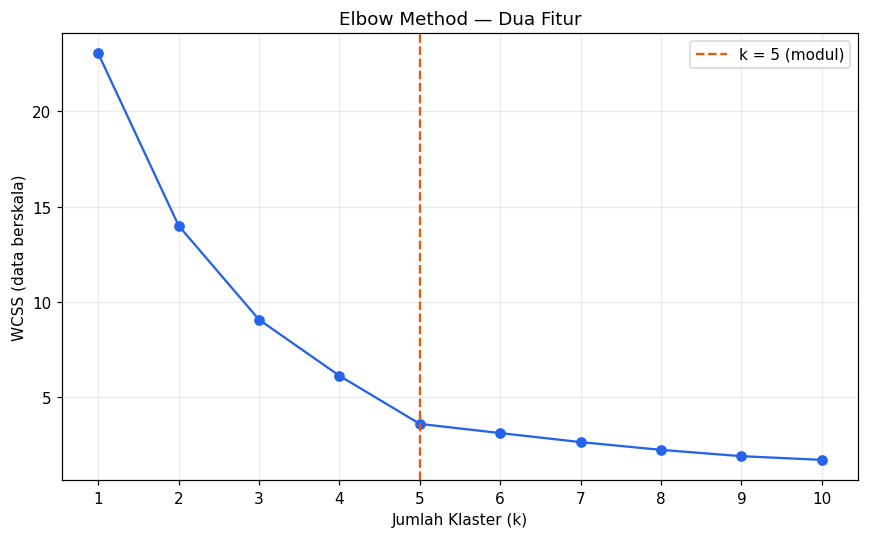

In [5]:
scaler_2d = MinMaxScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

def evaluate_k(X_scaled):
    rows = []
    for k in range(1, 11):
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
        labels = model.fit_predict(X_scaled)
        rows.append({
            "k": k,
            "WCSS": model.inertia_,
            "Silhouette": silhouette_score(X_scaled, labels) if k > 1 else np.nan,
        })
    return pd.DataFrame(rows)

def plot_elbow(results, chosen_k, title):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(results["k"], results["WCSS"], marker="o", color="#2563eb")
    ax.axvline(chosen_k, linestyle="--", color="#ea580c", label=f"k = {chosen_k} (modul)")
    ax.set(title=title, xlabel="Jumlah Klaster (k)", ylabel="WCSS (data berskala)")
    ax.set_xticks(results["k"])
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()

eval_2d = evaluate_k(X_2d_scaled)
display(eval_2d.round(4))
plot_elbow(eval_2d, 5, "Elbow Method — Dua Fitur")

## 6. K-Means dua fitur — k = 5
Lima klaster digunakan sesuai modul. Centroid merupakan pusat setiap kelompok dan ditampilkan kembali dalam satuan asli melalui `inverse_transform`. Nomor klaster hanya label, bukan peringkat pelanggan.

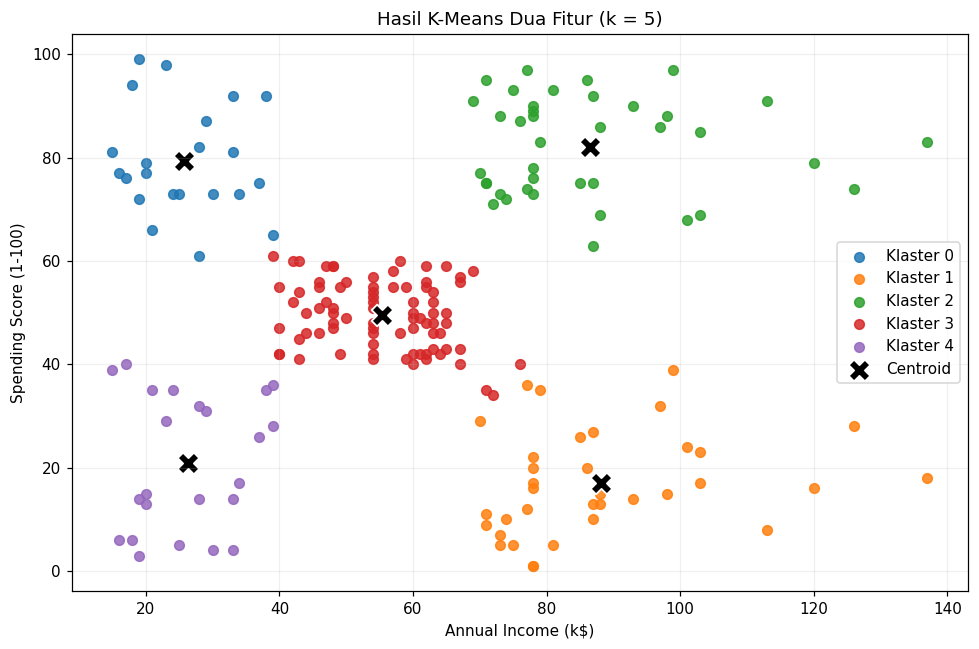

In [6]:
kmeans_2d = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=N_INIT)
labels_2d = kmeans_2d.fit_predict(X_2d_scaled)
df["Cluster_2D"] = labels_2d
centers_2d = scaler_2d.inverse_transform(kmeans_2d.cluster_centers_)
colors = plt.get_cmap("tab10").colors

fig, ax = plt.subplots(figsize=(9, 6))
for cluster in range(5):
    mask = labels_2d == cluster
    ax.scatter(X_2d.loc[mask, features_2d[0]], X_2d.loc[mask, features_2d[1]],
               color=colors[cluster], label=f"Klaster {cluster}", s=40, alpha=0.85)
ax.scatter(centers_2d[:, 0], centers_2d[:, 1], marker="X", s=200,
           color="black", edgecolor="white", linewidth=1.2, label="Centroid")
ax.set(title="Hasil K-Means Dua Fitur (k = 5)",
       xlabel="Annual Income (k$)", ylabel="Spending Score (1-100)")
ax.legend(loc="best")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 7. Ringkasan klaster dua fitur
Jumlah anggota dan rata-rata fitur digunakan untuk memahami profil pelanggan pada setiap klaster. Istilah tinggi/rendah bersifat relatif terhadap dataset, bukan ambang bisnis.

In [7]:
summary_2d = df.groupby("Cluster_2D").agg(
    Jumlah_Pelanggan=("CustomerID", "size"),
    Rata_Income=("Annual Income (k$)", "mean"),
    Rata_Spending=("Spending Score (1-100)", "mean"),
)
display(summary_2d.round(2))
display(pd.DataFrame(centers_2d, columns=features_2d).rename_axis("Cluster_2D").round(2))
print(f"Silhouette dua fitur: {silhouette_score(X_2d_scaled, labels_2d):.4f}")
assert summary_2d["Jumlah_Pelanggan"].sum() == len(df)

,Jumlah_Pelanggan,Rata_Income,Rata_Spending
Cluster_2D,,,
0,22,25.73,79.36
1,35,88.20,17.11
2,39,86.54,82.13
3,81,55.30,49.52
4,23,26.30,20.91


,Annual Income (k$),Spending Score (1-100)
Cluster_2D,,
0,25.73,79.36
1,88.20,17.11
2,86.54,82.13
3,55.30,49.52
4,26.30,20.91


Silhouette dua fitur: 0.5595


## 8. Visualisasi awal tiga fitur
Usia ditambahkan untuk melihat perbedaan kelompok pelanggan dari sisi demografi. Grafik 3D menggunakan usia, pendapatan tahunan, dan skor belanja.

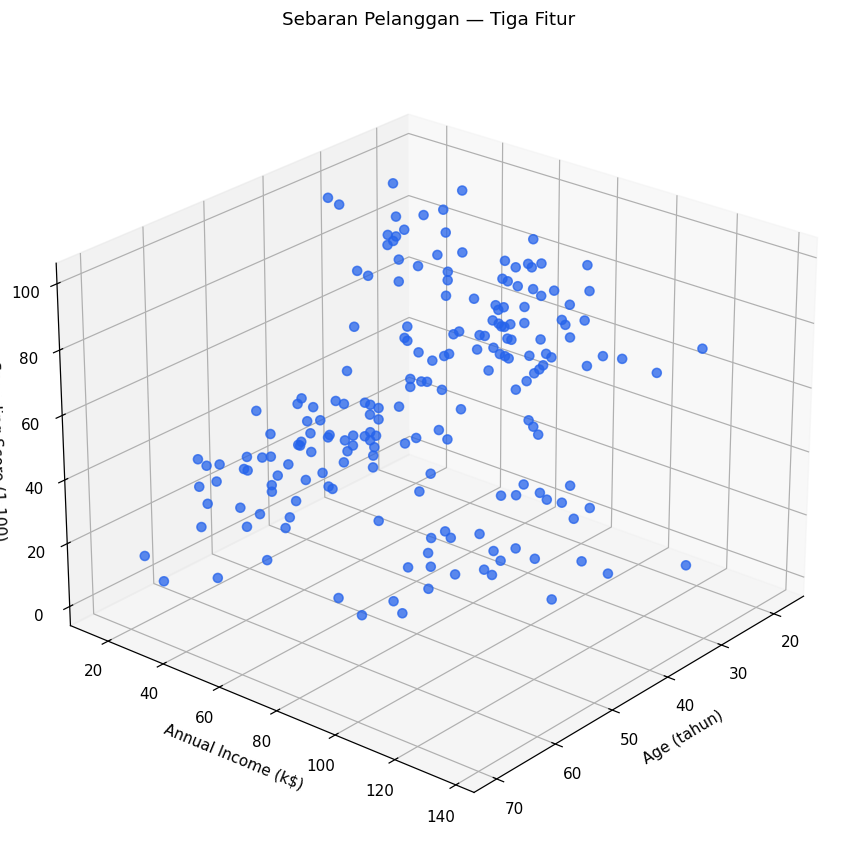

In [8]:
X_3d = df[features_3d].copy()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_3d["Age"], X_3d["Annual Income (k$)"], X_3d["Spending Score (1-100)"],
           color="#2563eb", s=35, alpha=0.75)
ax.set(xlabel="Age (tahun)", ylabel="Annual Income (k$)",
       zlabel="Spending Score (1-100)", title="Sebaran Pelanggan — Tiga Fitur")
ax.view_init(elev=25, azim=40)
fig.tight_layout()
plt.show()

## 9. Scaling dan Elbow Method — tiga fitur
Scaling dihitung ulang karena ruang fitur kini mencakup usia. Enam klaster dipakai sesuai contoh modul. Elbow merupakan pertimbangan visual, bukan bukti bahwa satu nilai k selalu paling optimal.

,k,WCSS,Silhouette
0,1,37.4015,NaN
1,2,22.5608,0.3652
2,3,17.3701,0.3650
3,4,12.6503,0.3923
4,5,10.3040,0.4061
5,6,8.3980,0.4231
6,7,7.1402,0.4249
7,8,6.2517,0.4159
8,9,5.5001,0.4294
9,10,5.0178,0.3986


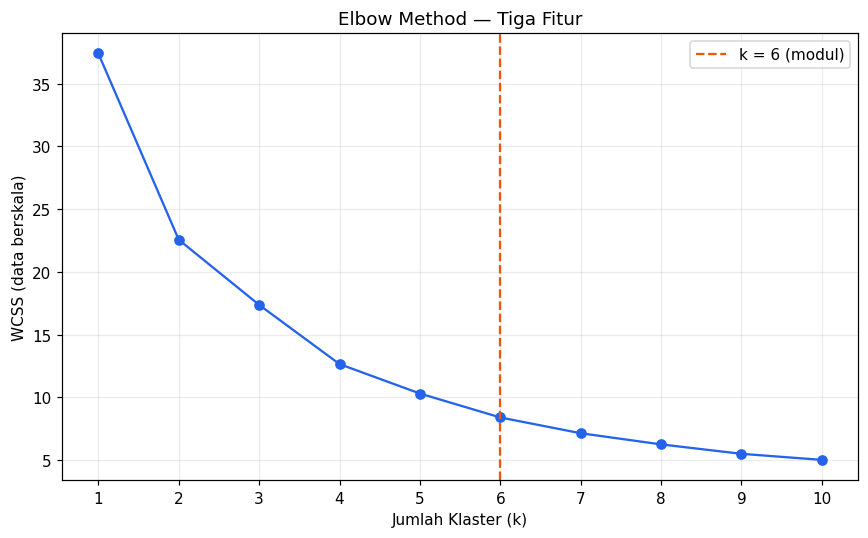

In [9]:
scaler_3d = MinMaxScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d)
eval_3d = evaluate_k(X_3d_scaled)
display(eval_3d.round(4))
plot_elbow(eval_3d, 6, "Elbow Method — Tiga Fitur")

## 10. K-Means tiga fitur — k = 6
Model dilatih pada data berskala dan hasilnya divisualisasikan dalam satuan asli. Penambahan usia dapat mengubah pembagian klaster; label 2D dan 3D tidak dapat dibandingkan hanya berdasarkan nomornya.

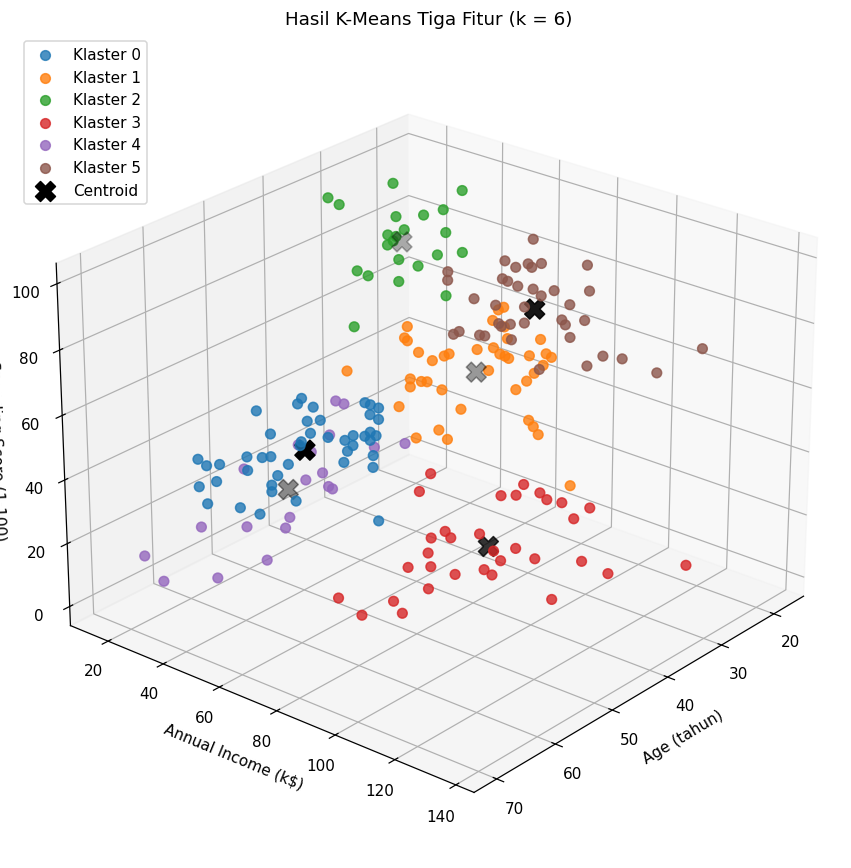

In [10]:
kmeans_3d = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=N_INIT)
labels_3d = kmeans_3d.fit_predict(X_3d_scaled)
df["Cluster_3D"] = labels_3d
centers_3d = scaler_3d.inverse_transform(kmeans_3d.cluster_centers_)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
for cluster in range(6):
    mask = labels_3d == cluster
    points = X_3d.loc[mask]
    ax.scatter(points["Age"], points["Annual Income (k$)"], points["Spending Score (1-100)"],
               color=colors[cluster], s=40, alpha=0.8, label=f"Klaster {cluster}")
ax.scatter(centers_3d[:, 0], centers_3d[:, 1], centers_3d[:, 2],
           color="black", marker="X", s=170, label="Centroid")
ax.set(xlabel="Age (tahun)", ylabel="Annual Income (k$)",
       zlabel="Spending Score (1-100)", title="Hasil K-Means Tiga Fitur (k = 6)")
ax.view_init(elev=25, azim=40)
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.0))
fig.tight_layout()
plt.show()

## 11. Ringkasan klaster tiga fitur dan evaluasi
Silhouette mengukur kekompakan dan keterpisahan klaster pada ruang fitur yang digunakan (rentang −1 sampai 1; lebih tinggi biasanya lebih baik). Nilai 2D dan 3D tidak menjadi perbandingan langsung kualitas model karena ruang fiturnya berbeda.

In [11]:
summary_3d = df.groupby("Cluster_3D").agg(
    Jumlah_Pelanggan=("CustomerID", "size"),
    Rata_Usia=("Age", "mean"),
    Rata_Income=("Annual Income (k$)", "mean"),
    Rata_Spending=("Spending Score (1-100)", "mean"),
)
display(summary_3d.round(2))
display(pd.DataFrame(centers_3d, columns=features_3d).rename_axis("Cluster_3D").round(2))
print(f"Silhouette tiga fitur: {silhouette_score(X_3d_scaled, labels_3d):.4f}")
assert summary_3d["Jumlah_Pelanggan"].sum() == len(df)
display(df.head())

,Jumlah_Pelanggan,Rata_Usia,Rata_Income,Rata_Spending
Cluster_3D,,,,
0,45,56.33,54.27,49.07
1,41,26.71,55.10,47.71
2,22,25.27,25.73,79.36
3,33,41.94,88.94,16.97
4,20,46.25,26.75,18.35
5,39,32.69,86.54,82.13


,Age,Annual Income (k$),Spending Score (1-100)
Cluster_3D,,,
0,56.33,54.27,49.07
1,26.71,55.10,47.71
2,25.27,25.73,79.36
3,41.94,88.94,16.97
4,46.25,26.75,18.35
5,32.69,86.54,82.13


Silhouette tiga fitur: 0.4231


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_2D,Cluster_3D
0,1,Male,19,15,39,4,1
1,2,Male,21,15,81,0,2
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,0,2
4,5,Female,31,17,40,4,1


## 12. Kesimpulan
- K-Means membagi pelanggan menjadi kelompok berdasarkan kemiripan fitur, bukan berdasarkan label yang sudah tersedia.
- Dua fitur menghasilkan lima kelompok untuk segmentasi pendapatan dan perilaku belanja. Penambahan usia menghasilkan enam kelompok dengan informasi demografi.
- Scaling dilakukan secara konsisten pada Elbow Method dan model akhir. Karena itu, hasil dapat berbeda dari contoh modul yang melatih model akhir pada data tanpa scaling.
- Profil setiap kelompok harus dibaca dari tabel rata-rata dan centroid. Nomor klaster tidak memiliki makna tinggi/rendah.
- Nilai k mengikuti modul; pilihan untuk penggunaan nyata perlu mempertimbangkan elbow, evaluasi klaster, dan tujuan segmentasi.

Sel berikut menyimpan hasil klasterisasi agar dapat digunakan kembali.

In [12]:
output_path = Path("Mall_Customers_Hasil_KMeans.csv")
df.to_csv(output_path, index=False)
print(f"Hasil tersimpan: {output_path.name}")

Hasil tersimpan: Mall_Customers_Hasil_KMeans.csv
